In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools
from torch.ao.quantization.observer import MinMaxObserver

In [3]:
#custom 4-bit quantization transform function for the MNIST images
class FourBitQuantize:
    def __call__(self, image):
        #quantize the image to 4-bit precision
        quantized_image = torch.floor(image * 15.0) / 15.0

        return quantized_image

In [4]:
#custom 1-bit quantization transform function for the MNIST images
class OneBitQuantize:
    def __call__(self, image):
        #quantize the image to 2-bit precision(round to nearest integer 0 or 1)
        quantized_image = torch.round(image)

        return quantized_image

In [5]:
#create a custom dataset to generate multiple augmented images
class AugmentedDataset(torch.utils.data.Dataset):
  def __init__(self, dataset, num_augments):
    self.dataset = dataset
    self.num_augments = num_augments  # Number of augmentations per original image

  def __len__(self):
    return len(self.dataset) * self.num_augments  #augmented dataset size

  def __getitem__(self, index):
    #map index to original dataset
    original_index = index // self.num_augments
    img, label = self.dataset[original_index]
    return img, label

In [6]:
#Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Resizes to 28x28
    transforms.ToTensor(),  # Converts to tensor
    #transforms.RandomRotation(15),  # Rotate images randomly up to ±15°
    #transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Small shifts, scaling
    #transforms.RandomCrop(14, padding=4),  # Randomly crop with padding
    #transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3)),  # Random erasing
    OneBitQuantize()  # Binarize images (custom function)
])

test_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    OneBitQuantize()
])



batch_size = 128
#Load MNIST dataset and apply transformations
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform) #60k images
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform) #10k images



#split the training dataset into training and validation datasets
train_size = int(0.83 * len(full_train_dataset)) #50k for training
val_size = len(full_train_dataset) - train_size #10k for validation
train_dataset, _ = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

#create a separate validation dataset with the test transforms
val_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=test_transform)

#subset only the remaining 10% of the data for validation
_, val_dataset = torch.utils.data.random_split(val_dataset, [train_size, val_size])

#make 4 augmented copies of each training image
train_dataset = AugmentedDataset(train_dataset, num_augments=4)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [8]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(dataset), size=(1,)).item()
      img, label = dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

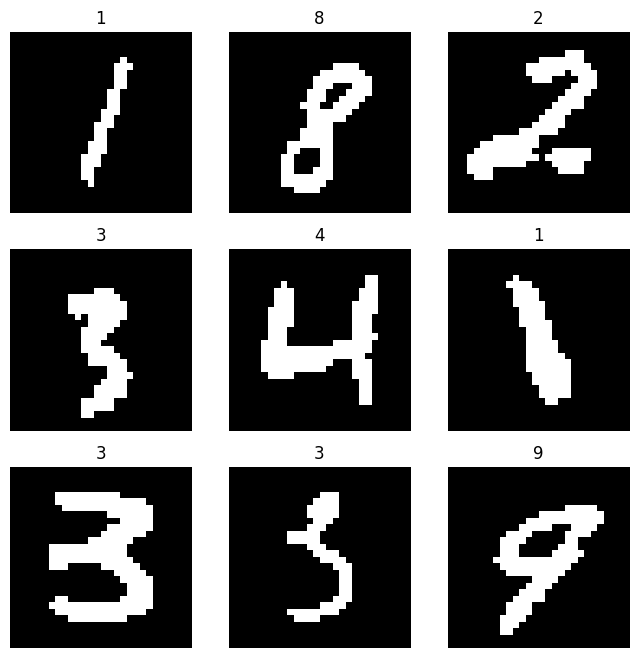

In [9]:
show_images(train_dataset, 3, 3)

In [10]:
activation_quantizer = torch.ao.quantization.FakeQuantize(
    observer=torch.quantization.MinMaxObserver,
    quant_min=0,
    quant_max=1,
    dtype=torch.qint8,
    qscheme=torch.per_tensor_affine
)

In [11]:
from torch.ao.quantization import FakeQuantize
from torch.ao.quantization.observer import MinMaxObserver
weight_quantizer_quint8 = FakeQuantize(
    observer=MinMaxObserver,
    quant_min=0,
    quant_max=255,
    dtype=torch.quint8,
    qscheme=torch.per_tensor_affine
)
weight_quantizer_qint8 = FakeQuantize(
    observer=MinMaxObserver,
    quant_min=-128,
    quant_max=127,
    dtype=torch.qint8,
    qscheme=torch.per_tensor_affine
)

In [12]:
tensor = nn.Parameter(torch.rand(256, 256))
tensor1 = torch.quantize_per_tensor(tensor.data, scale=0.1, zero_point=0, dtype=torch.quint8)
tensor1

tensor([[0.5000, 0.1000, 0.3000,  ..., 0.6000, 1.0000, 0.8000],
        [0.1000, 0.4000, 0.5000,  ..., 0.1000, 0.8000, 0.9000],
        [0.4000, 0.9000, 0.7000,  ..., 0.5000, 0.1000, 0.1000],
        ...,
        [0.6000, 0.4000, 0.2000,  ..., 0.3000, 1.0000, 0.1000],
        [0.3000, 0.4000, 0.4000,  ..., 0.4000, 0.9000, 0.5000],
        [0.7000, 0.0000, 0.7000,  ..., 0.2000, 0.5000, 0.3000]],
       size=(256, 256), dtype=torch.quint8,
       quantization_scheme=torch.per_tensor_affine, scale=0.1, zero_point=0)

In [13]:
out1 = torch.rand(3, 5)
out2 = torch.rand(3, 5)
out3 = torch.rand(3, 5)
all = torch.cat([out1, out2, out3], dim=1)
torch.cat([all[:, :3], all[:, 5:7], all[:, 10:12]], dim=1)

tensor([[0.0838, 0.3755, 0.3224, 0.2866, 0.1738, 0.5737, 0.9801],
        [0.9034, 0.3844, 0.3564, 0.4808, 0.4583, 0.8039, 0.1660],
        [0.5429, 0.9562, 0.6834, 0.9575, 0.7872, 0.2781, 0.8766]])

In [23]:
#this class is a binary activation module that is compatible with forward hooks, expecting a quantized input
class SigmoidBinaryQuant(nn.Module):
  def __init__(self):
    super(SigmoidBinaryQuant, self).__init__()

    self.sigmoid = nn.Sigmoid()

    self.quant = torch.ao.quantization.QuantStub()
    self.dequant = torch.ao.quantization.DeQuantStub()

  def forward(self, x):
    x = self.dequant(x)
    x = self.sigmoid(x)
    x = torch.where(x > 0.5, 1.0, 0.0)
    x = self.quant(x)
    return x

#Core
class Core(nn.Module):
  def __init__(self, num_inputs, num_outputs):
    super(Core, self).__init__()
    self.fc = nn.Linear(num_inputs, num_outputs, bias=False)

    self.add_fn = torch.ao.nn.quantized.FloatFunctional()

    self.sigmoid = SigmoidBinaryQuant()

  def forward(self, x, bias):
    x_weighted = self.fc(x)

    out = self.add_fn.add_scalar(x_weighted, float(bias.data))  #simulating subtraction with add

    out = self.sigmoid(out)

    return out


#Layer 0(Cores (1, 0); (2,0); (3,0))
class CustomLayer0_Column0(nn.Module):
  def __init__(self):
    super(CustomLayer0_Column0, self).__init__()

    #create three sublayers, each with 128 input units and 256 output units
    self.core1 = Core(256, 256)
    self.core2 = Core(256, 256)
    self.core3 = Core(256, 256)

    self.add_tensor_fn = torch.ao.nn.quantized.FloatFunctional()

  def forward(self, x, bias):
    #core 1 input
    x1_1 = x[:, 0:256]
    x1_2 = x[:, 224:480]
    x1_3 = x[:, 448:704]
    x1_4 = torch.cat([x[:, 672:784], x[:, 0:144]], dim=1)
    x1 = self.add_tensor_fn.add(x1_1, self.add_tensor_fn.add(x1_2, self.add_tensor_fn.add(x1_3, x1_4)))

    #core 2 input
    x2_1 = x[:, 80:336]
    x2_2 = x[:, 304:560]
    x2_3 = x[:, 528:784]
    x2_4 = torch.cat([x[:, 0:64], x[:, 144:336]], dim=1)
    x2 = self.add_tensor_fn.add(x2_1, self.add_tensor_fn.add(x2_2, self.add_tensor_fn.add(x2_3, x2_4)))

    #core 3 input
    x3_1 = x[:, 144:400]
    x3_2 = x[:, 368:624]
    x3_3 = torch.cat([x[:, 592:784], x[:, 0:64]], dim=1)
    x3_4 = x[:, 32:288]
    x3 = self.add_tensor_fn.add(x3_1, self.add_tensor_fn.add(x3_2, self.add_tensor_fn.add(x3_3, x3_4)))

    #pass each vector to a core
    out1 = self.core1(x1, bias)
    out2 = self.core2(x2, bias)
    out3 = self.core3(x3, bias)


    #each out has its own quantization scale and zero-point, which could lead to innacuracies when concatenating
    #requantizing all tensors to a normalized scale
    if out1.is_quantized:
      common_scale = out1.q_scale()
      common_zero_point = out1.q_zero_point()
      common_dtype = out1.dtype

      #requantize all tensors to the common scale and zero-point
      out1 = torch.quantize_per_tensor(out1.dequantize(), scale=common_scale, zero_point=common_zero_point, dtype=common_dtype)
      out2 = torch.quantize_per_tensor(out2.dequantize(), scale=common_scale, zero_point=common_zero_point, dtype=common_dtype)
      out3 = torch.quantize_per_tensor(out3.dequantize(), scale=common_scale, zero_point=common_zero_point, dtype=common_dtype)


    return torch.cat([out1, out2, out3], dim=1)



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self, num_inputs):
    super(OutputLayer, self).__init__()

    self.fc = nn.Linear(num_inputs, 10, bias=False)

    self.add_fn = torch.ao.nn.quantized.FloatFunctional()

  def forward(self, x, bias): #receives an input of 128 elements, size = [64, 128]
    x_weighted = self.fc(x)

    out = self.add_fn.add_scalar(x_weighted, float(bias.data))

    return out


#Overall Architecture
class Part7_a(nn.Module):
  def __init__(self):
    super(Part7_a, self).__init__()
    #layers
    self.layer0_col0 = CustomLayer0_Column0()
    self.output = OutputLayer(num_inputs=768)

    self.bias = nn.Parameter(torch.tensor(0.0))

    self.softmax = nn.Softmax(dim=1)

    self.quant = torch.ao.quantization.QuantStub()  #quantize the inputs
    self.dequant = torch.ao.quantization.DeQuantStub()  #dequantize back to floating-point

  def forward(self, x):
    #self.bias = nn.Parameter(self.bias * 256 / 256) #single 8-bit bias

    x = self.quant(x)
    x = x.flatten(start_dim=1) #flatten the input
    x = self.layer0_col0(x, self.bias) #size: [batch_size, 768]
    x = self.output(x, self.bias)
    x = self.dequant(x)
    x = self.softmax(x) * 256 / 256 #8-bit softmax(softmax not supported with QAT)
    return x


In [24]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  model.to(device)
  print(device)
  best_val_accuracy = 0

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):

      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      inputs = inputs.to(device)
      labels = labels.to(device)

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights before the optimizer steps.
      # with torch.no_grad():  #disable gradient tracking
      #   for param in model.parameters():
      #     #project all weights to nonnegative values
      #     param.data = torch.clamp(param.data, min=0.00001)


      #     # #quantize all weights
      #     # #exclude conv and pooling layers from 8-bit quantization
      #     # if not isinstance(param, nn.Conv2d) and not isinstance(param, nn.MaxPool2d):
      #     #   #param.data = weight_quantizer(param.data)
      #     #   param.data = torch.round(param.data * 256) / 256


      # any_negative = False
      # #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    #validation phase
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
      for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        #forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        #statistics
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Print statistics after each epoch
    print(f"Epoch {epoch+1}/{epochs}, Learning Rate: {optimizer.param_groups[0]['lr']},")
    print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%,")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    if (val_accuracy >= best_val_accuracy):
      #save model
      torch.save(model.state_dict(), './pic_qat_step5_9.pth')
      best_val_accuracy = val_accuracy

    #step the scheduler at the end of each epoch (PART 5), for dynamic learning rates
    #scheduler.step()
    scheduler.step(val_loss)


  print("Training complete")



In [25]:
#hooks used to store activations
def evaluate_model_custom_binary(model, test_loader):
    model.eval()  # Set model to evaluation mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    correct = 0
    total = 0

    activations = []


    def get_activations_hook_fn(module, input, output): #forward hook(function ran in every forward pass)
      activations.append(output.detach().cpu().numpy()) #get the output of the activations and store it, int_repr shows the quantized activations

    activation_hooks = []

    for name, module in model.named_modules():
      if name in ('activation1','activation2'):  #apply hooks on hidden layers
        activation_hooks.append(module.register_forward_hook(get_activations_hook_fn))

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total

    #detach hooks after usage
    for hook in activation_hooks:
      hook.remove()

    #analyze activations from hooks
    if (len(activations) > 0):
      flattened_activations = np.concatenate([activation.flatten() for activation in activations]) #flatten all activations into a list
      np.random.shuffle(flattened_activations)
      activations_samples = flattened_activations[:100]
      print(activations_samples)
      print(len(activations_samples))

    return accuracy

In [26]:
#model = Chip_Architecture_Step1()
#model_qat = BasicNetwork_NoCNN()
model_qat = Part7_a()
print(model_qat)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

Part7_a(
  (layer0_col0): CustomLayer0_Column0(
    (core1): Core(
      (fc): Linear(in_features=256, out_features=256, bias=False)
      (add_fn): FloatFunctional(
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): QuantStub()
        (dequant): DeQuantStub()
      )
    )
    (core2): Core(
      (fc): Linear(in_features=256, out_features=256, bias=False)
      (add_fn): FloatFunctional(
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): QuantStub()
        (dequant): DeQuantStub()
      )
    )
    (core3): Core(
      (fc): Linear(in_features=256, out_features=256, bias=False)
      (add_fn): FloatFunctional(
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): QuantStub()
        (dequant): DeQuantStub()
      )
    )
    (add_t

In [27]:
model_qat.eval() #model needs to be in eval mode for fusing layers
model_qat.qconfig = torch.ao.quantization.get_default_qconfig('x86')
model_qat_fused = model_qat
#model_fused = torch.ao.quantization.fuse_modules(model,[['conv1', 'flatten', 'fc']]) ---Not sure if necessary
#model_fused = torch.ao.quantization.fuse_modules(model_qat, [['conv', 'bn', 'relu']])

In [28]:
#prepare the model for quantization training, model needs to be in train
model_qat_prepared = torch.ao.quantization.prepare_qat(model_qat_fused.train())

In [29]:
model_qat_prepared

Part7_a(
  (layer0_col0): CustomLayer0_Column0(
    (core1): Core(
      (fc): Linear(
        in_features=256, out_features=256, bias=False
        (weight_fake_quant): PerChannelMinMaxObserver(min_val=tensor([]), max_val=tensor([]))
        (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
      )
      (add_fn): FloatFunctional(
        (activation_post_process): HistogramObserver(min_val=inf, max_val=-inf)
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid(
          (activation_post_process): FixedQParamsFakeQuantize(
            fake_quant_enabled=tensor([1], dtype=torch.uint8), observer_enabled=tensor([1], dtype=torch.uint8), scale=tensor([0.0039]), zero_point=tensor([0], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine
            (activation_post_process): FixedQParamsObserver()
          )
        )
        (quant): QuantStub(
          (activation_post_process): HistogramObserver(mi

In [30]:
#test output shape
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    output = model_qat_prepared(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

Output shape: torch.Size([128, 10])


In [31]:
def create_sgd_optimizer(model, learning_rate, weight_decay=0.01, momentum=0.8):
  return torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

In [32]:
def create_adam_optimizer(model, learning_rate):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [33]:
def train_test_model_qat(model, learning_rate=0.01, num_epochs=10):
  loss_fn = nn.CrossEntropyLoss()
  print(learning_rate)
  optimizer = create_adam_optimizer(model, learning_rate)
  #optimzer = create_sgd_optimizer(model, learning_rate)

  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 100, gamma = 1) #essentially no scheduler
  #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 5, 7], gamma=0.1)
  #scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1) #learning rate annealing (STEP 5), standard step decreases the lr by a scale gamma every number of epochs
  #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.0001) #learning rate annealing(STEP 5), cosine gradually decreases the learning rate more and more, good for sensitive weights
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=0.00001) #learning rate annealing (STEP 5), automatically reduces lr when val loss plateaus

  train_model_with_pgd_qat(model, train_loader, val_loader, optimizer, scheduler, loss_fn=loss_fn, epochs=num_epochs)


  model.eval()
  #model_int8 = torch.ao.quantization.convert(model, inplace=True)
  #print(model_int8)
  #model.qconfig = torch.quantization.get_default_qconfig('fbgemm')
  print("Testing accuracy: " + str(evaluate_model_custom_binary(model, test_loader)))
  return model

In [41]:
learning_rate = 0.005
num_epochs = 10

In [42]:
model_qat_trained = train_test_model_qat(model_qat_prepared, learning_rate, num_epochs)

0.005
cpu
Epoch 1/10, Learning Rate: 0.005,
Train Loss: 1.6457, Train Accuracy: 82.81%,
Val Loss: 1.6297, Val Accuracy: 84.16%
Epoch 2/10, Learning Rate: 0.005,
Train Loss: 1.6226, Train Accuracy: 84.92%,
Val Loss: 1.6180, Val Accuracy: 85.06%
Epoch 3/10, Learning Rate: 0.005,
Train Loss: 1.6141, Train Accuracy: 85.66%,
Val Loss: 1.6101, Val Accuracy: 85.84%
Epoch 4/10, Learning Rate: 0.005,
Train Loss: 1.6070, Train Accuracy: 86.34%,
Val Loss: 1.6148, Val Accuracy: 85.36%
Epoch 5/10, Learning Rate: 0.005,
Train Loss: 1.6026, Train Accuracy: 86.74%,
Val Loss: 1.6028, Val Accuracy: 86.57%
Epoch 6/10, Learning Rate: 0.005,
Train Loss: 1.5989, Train Accuracy: 87.10%,
Val Loss: 1.6021, Val Accuracy: 86.60%
Epoch 7/10, Learning Rate: 0.005,
Train Loss: 1.5959, Train Accuracy: 87.40%,
Val Loss: 1.5976, Val Accuracy: 87.14%
Epoch 8/10, Learning Rate: 0.005,
Train Loss: 1.5932, Train Accuracy: 87.64%,
Val Loss: 1.5894, Val Accuracy: 87.95%
Epoch 9/10, Learning Rate: 0.005,
Train Loss: 1.5907, 

In [43]:
model_qat_trained.eval()
model_qat_trained(torch.rand(1,28,28))

tensor([[0.0391, 0.0000, 0.9570, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000,
         0.0000]], grad_fn=<DivBackward0>)

In [44]:
model_qat_converted = torch.ao.quantization.convert(model_qat_trained)
model_qat_converted.eval()

Part7_a(
  (layer0_col0): CustomLayer0_Column0(
    (core1): Core(
      (fc): QuantizedLinear(in_features=256, out_features=256, scale=0.03762781247496605, zero_point=66, qscheme=torch.per_channel_affine)
      (add_fn): QFunctional(
        scale=1.0, zero_point=0
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
        (dequant): DeQuantize()
      )
    )
    (core2): Core(
      (fc): QuantizedLinear(in_features=256, out_features=256, scale=0.045639242976903915, zero_point=62, qscheme=torch.per_channel_affine)
      (add_fn): QFunctional(
        scale=1.0, zero_point=0
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
        (dequant): DeQuantize()
      )

In [45]:
model_qat_converted(torch.rand(1,28,28))
evaluate_model_custom_binary(model_qat_converted, test_loader)

81.61

In [46]:
# Run a sample input through the converted model and print dtype at each step
sample_input = torch.randn(1, 784)  # Example input

print(f"Original input dtype: {sample_input.dtype}")

x = model_qat_converted.quant(sample_input)  # Manually quantize input
print(f"After QuantStub: {x.dtype}")  # Should be `torch.quint8` or `torch.qint8`

x = model_qat_converted.layer0_col0(x, model_qat_converted.bias)
print(f"After layer0_col0: {x.dtype}")

x = model_qat_converted.output(x, model_qat_converted.bias)
print(f"After output layer: {x.dtype}")

x = model_qat_converted.dequant(x)  # Manually dequantize before final softmax
print(f"After DeQuantStub: {x.dtype}")

x = model_qat_converted.softmax(x)
print(f"After softmax: {x.dtype}")


Original input dtype: torch.float32
After QuantStub: torch.quint8
After layer0_col0: torch.quint8
After output layer: torch.quint8
After DeQuantStub: torch.float32
After softmax: torch.float32


In [47]:
import random
def sample_quantized_weights(model):
  """Samples 100 weights from the quantized model and verifies their type."""
  model_qat = torch.ao.quantization.convert(model)  #ensure model is quantized

  print("Quantized Model Structure:", model_qat)
  model_qat.eval()

  #access the raw quantized weights (without parentheses)
  print("Raw Quantized Weights (fc1) - Quantized (qint8):", model_qat.layer0_col0.core1.fc.weight())  #this should show quantized weights in their float representation
  print("Raw Quantized Weights (fc1) - Quantized (int8):", model_qat.layer0_col0.core1.fc.weight().int_repr())  #this should show quantized weights in their integer representations

  #now dequantize and sample
  all_weights = torch.cat([
    model_qat.layer0_col0.core1.fc.weight().dequantize().view(-1),
  ]).cpu().detach().numpy()

  all_weights_quant = torch.cat([
    model_qat.layer0_col0.core1.fc.weight().int_repr().view(-1),
  ]).cpu().detach().numpy()


  sampled_weights = random.sample(list(all_weights), 100)
  sampled_quant_weights = random.sample(list(all_weights_quant), 100)
  print("Sampled Weights:", sampled_weights)
  print("Sampled Quantized Weights:", sampled_quant_weights)

#example usage:
sample_quantized_weights(model_qat_converted)

Quantized Model Structure: Part7_a(
  (layer0_col0): CustomLayer0_Column0(
    (core1): Core(
      (fc): QuantizedLinear(in_features=256, out_features=256, scale=0.03762781247496605, zero_point=66, qscheme=torch.per_channel_affine)
      (add_fn): QFunctional(
        scale=1.0, zero_point=0
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
        (dequant): DeQuantize()
      )
    )
    (core2): Core(
      (fc): QuantizedLinear(in_features=256, out_features=256, scale=0.045639242976903915, zero_point=62, qscheme=torch.per_channel_affine)
      (add_fn): QFunctional(
        scale=1.0, zero_point=0
        (activation_post_process): Identity()
      )
      (sigmoid): SigmoidBinaryQuant(
        (sigmoid): Sigmoid()
        (quant): Quantize(scale=tensor([0.0079]), zero_point=tensor([0]), dtype=torch.quint8)
        (deq